# Module 4: Similarity and Cluster Insights

## Objectives

- Analyze average similarity scores within clusters.
- Compare cluster size and issue type.
- Visualize performance gaps using boxplots and scatter plots.
- Identify key problem clusters.

This notebook performs analytical visualizations to understand cluster behaviour and ticket similarity.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [4]:
df = pd.read_csv("../data/processed/cleaned_IT_Support_Tickets.csv")

In [5]:
print(df.shape)

df.head()

(10000, 32)


,Ticket_ID,Created_Date,Resolution_Date,Status,Priority,Ticket_Type,Category,Country,Cluster_ID,Cluster_Name,...,Tags,Product,Customer_Satisfaction,Escalation_Level,Region,Device_Type,Operating_System,Resolution_Notes,Resolution_Duration,Priority_Score
0,Tkt000001,2026-05-20,2026-05-23 17:20:00,Open,Critical,Incident,Software,Germany,Cl001,Network,...,Vpn,Office365,1,L1,Apac,Laptop,Ubuntu,Resolved After Troubleshooting.,89.333333,4
1,Tkt000002,2026-05-02,2026-05-06 09:33:00,Closed,High,Request,Network,India,Cl002,Login,...,Network,Erp,2,L2,Emea,Laptop,Windows 11,Resolved After Troubleshooting.,105.550000,3
2,Tkt000003,2025-05-30,2025-05-30 15:56:00,Open,Medium,Request,Email,Usa,Cl003,Software,...,Network,Erp,2,L2,Emea,Desktop,Macos,Resolved After Troubleshooting.,15.933333,2
3,Tkt000004,2025-08-23,2025-08-25 02:12:00,Closed,High,Problem,Security,Germany,Cl001,Software,...,Vpn,Office365,2,L3,Emea,Laptop,Ubuntu,Resolved After Troubleshooting.,50.200000,3
4,Tkt000005,2025-03-26,2025-03-30 09:31:00,Resolved,Critical,Problem,Security,Canada,Cl001,Login,...,Vpn,Erp,2,L3,NaN,Desktop,Ubuntu,Resolved After Troubleshooting.,105.516667,4


In [6]:
df.columns

Index(['Ticket_ID', 'Created_Date', 'Resolution_Date', 'Status', 'Priority',
       'Ticket_Type', 'Category', 'Country', 'Cluster_ID', 'Cluster_Name',
       'Similarity_Score', 'Similarity_Level', 'First_Response_Date',
       'Assigned_Agent', 'Team', 'SLA_Status', 'Reopened', 'Resolution_Code',
       'Department', 'Customer_ID', 'Channel', 'Description', 'Tags',
       'Product', 'Customer_Satisfaction', 'Escalation_Level', 'Region',
       'Device_Type', 'Operating_System', 'Resolution_Notes',
       'Resolution_Duration', 'Priority_Score'],
      dtype='str')

In [7]:
avg_similarity = df.groupby("Cluster_Name")["Similarity_Score"].mean()

avg_similarity

Cluster_Name
Login       0.743532
Network     0.742638
Software    0.747678
Name: Similarity_Score, dtype: float64

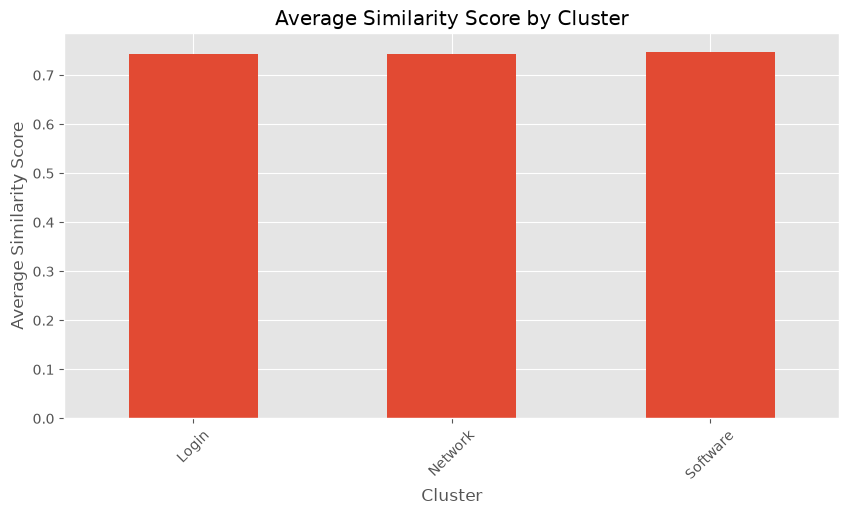

In [8]:
plt.figure(figsize=(10,5))

avg_similarity.plot(kind="bar")

plt.title("Average Similarity Score by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Similarity Score")

plt.xticks(rotation=45)

plt.show()

Clusters with higher similarity scores contain more closely related issues.

In [9]:
cluster_size = df["Cluster_Name"].value_counts()

cluster_size

Cluster_Name
Network     3370
Software    3346
Login       3284
Name: count, dtype: int64

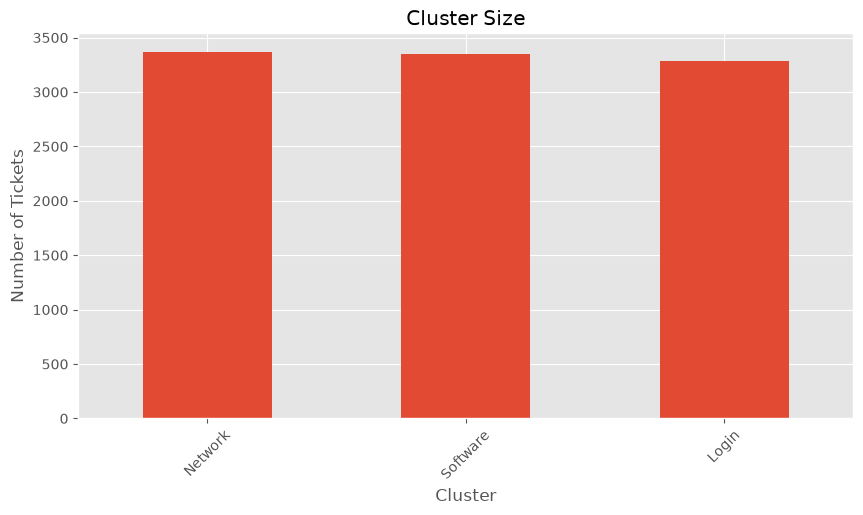

In [10]:
plt.figure(figsize=(10,5))

cluster_size.plot(kind="bar")

plt.title("Cluster Size")
plt.xlabel("Cluster")
plt.ylabel("Number of Tickets")

plt.xticks(rotation=45)

plt.show()

Some clusters receive significantly more tickets than others.

In [11]:
ticket_cluster = pd.crosstab(
    df["Cluster_Name"],
    df["Ticket_Type"]
)

ticket_cluster

Ticket_Type,Incident,Problem,Request
Cluster_Name,,,
Login,1063,1118,1103
Network,1157,1098,1115
Software,1080,1126,1140


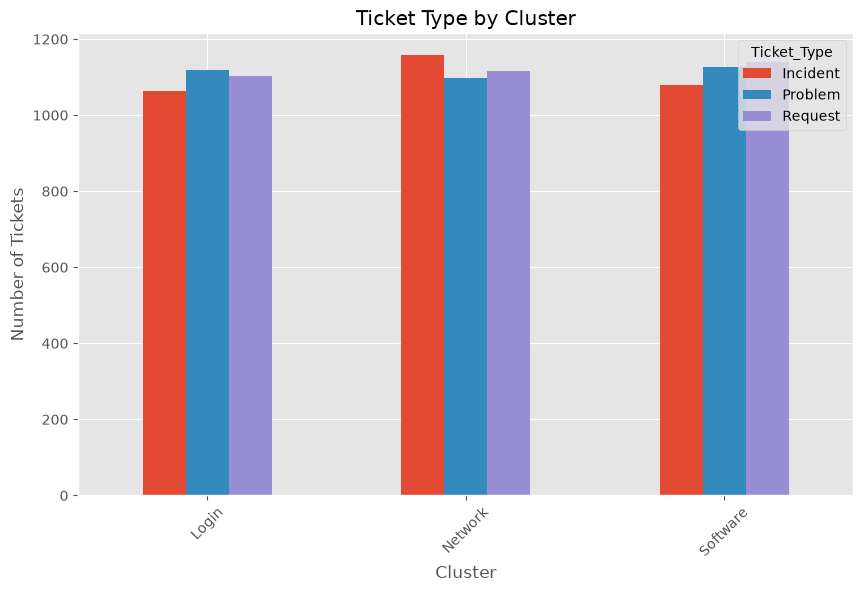

In [12]:
ticket_cluster.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Ticket Type by Cluster")

plt.xlabel("Cluster")

plt.ylabel("Number of Tickets")

plt.xticks(rotation=45)

plt.show()

Each cluster contains different proportions of Incident, Request, and Problem tickets.

In [13]:
priority_cluster = pd.crosstab(
    df["Cluster_Name"],
    df["Priority"]
)

priority_cluster

Priority,Critical,High,Low,Medium
Cluster_Name,,,,
Login,866,831,802,785
Network,870,822,828,850
Software,833,807,857,849


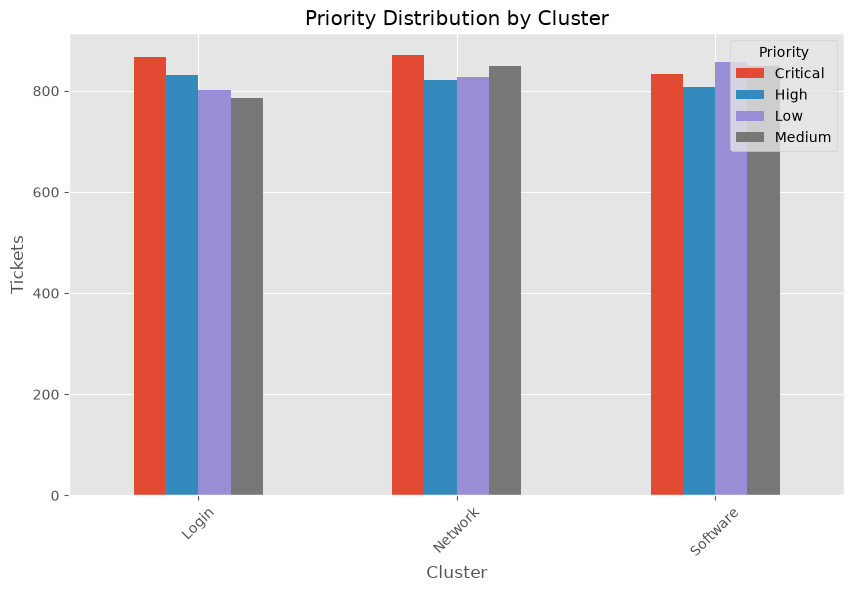

In [14]:
priority_cluster.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Priority Distribution by Cluster")

plt.xlabel("Cluster")

plt.ylabel("Tickets")

plt.xticks(rotation=45)

plt.show()

Some clusters contain a larger proportion of high-priority tickets.

<Figure size 1000x600 with 0 Axes>

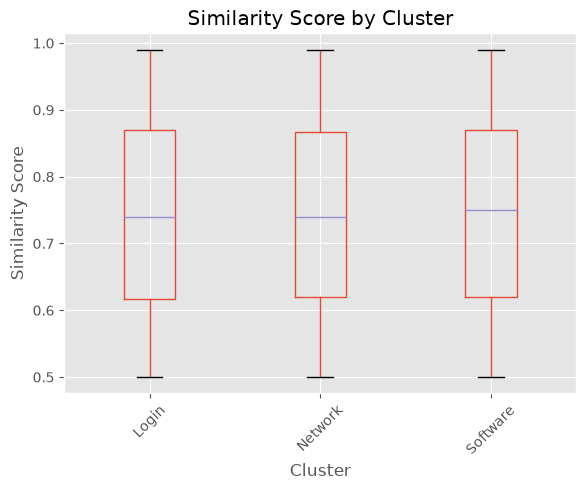

In [16]:
plt.figure(figsize=(10,6))

df.boxplot(
    column="Similarity_Score",
    by="Cluster_Name"
)

plt.title("Similarity Score by Cluster")

plt.suptitle("")

plt.xlabel("Cluster")

plt.ylabel("Similarity Score")

plt.xticks(rotation=45)

plt.show()

The boxplot shows score spread, median, and possible outliers.

<Figure size 1000x600 with 0 Axes>

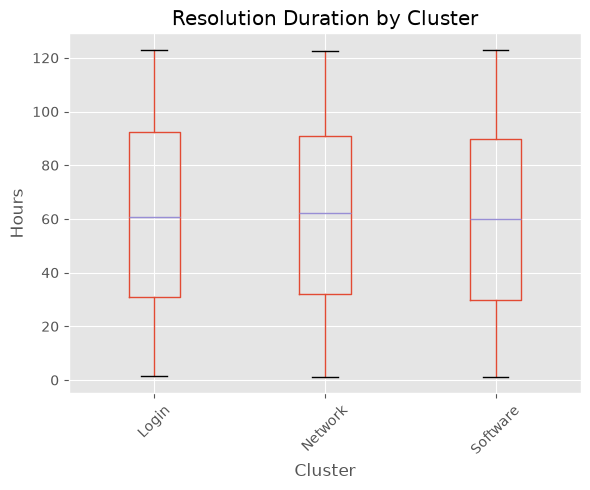

In [17]:
plt.figure(figsize=(10,6))

df.boxplot(
    column="Resolution_Duration",
    by="Cluster_Name"
)

plt.title("Resolution Duration by Cluster")

plt.suptitle("")

plt.xlabel("Cluster")

plt.ylabel("Hours")

plt.xticks(rotation=45)

plt.show()

Some clusters require significantly longer resolution times.

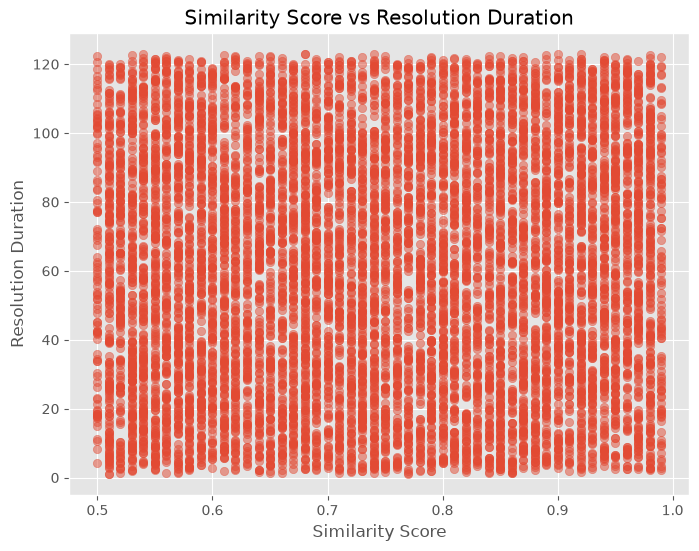

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Similarity_Score"],
    df["Resolution_Duration"],
    alpha=0.5
)

plt.title("Similarity Score vs Resolution Duration")

plt.xlabel("Similarity Score")

plt.ylabel("Resolution Duration")

plt.show()

The scatter plot helps identify whether similar tickets are resolved more quickly.

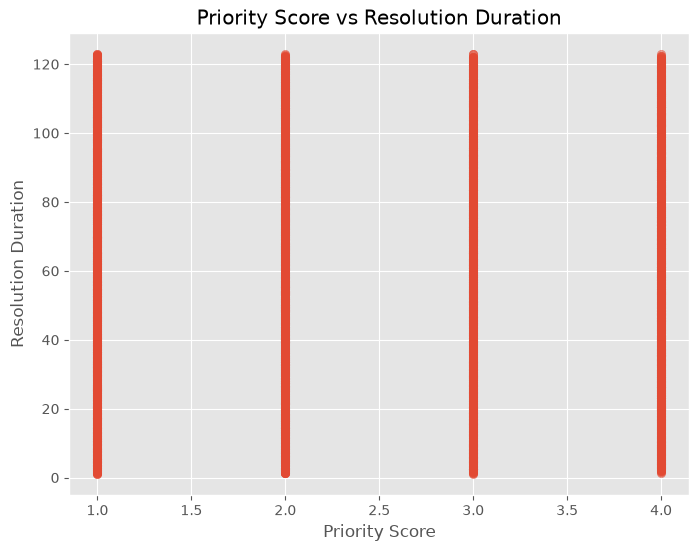

In [19]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Priority_Score"],
    df["Resolution_Duration"],
    alpha=0.5
)

plt.title("Priority Score vs Resolution Duration")

plt.xlabel("Priority Score")

plt.ylabel("Resolution Duration")

plt.show()

Higher-priority tickets may require different resolution times depending on the issue.

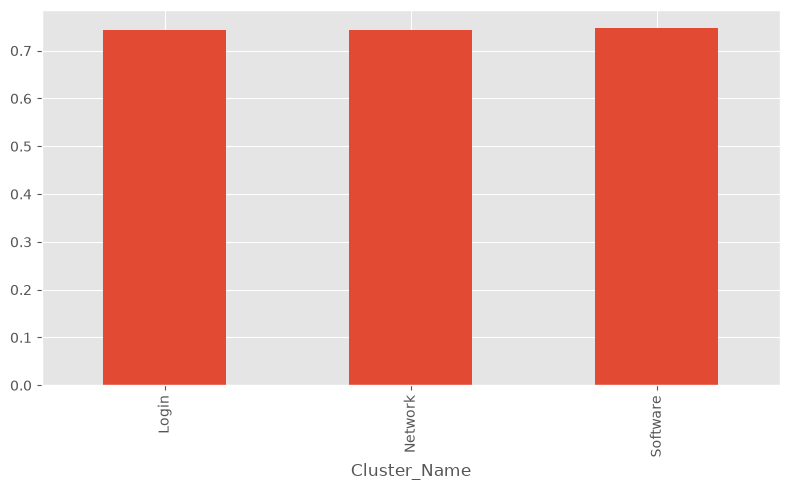

: 

In [ ]:
plt.figure(figsize=(8,5))

avg_similarity.plot(kind="bar")

plt.tight_layout()

plt.savefig("../reports/figures/avg_similarity_cluster.png")

plt.show()

# Module 4 Summary

## Key Patterns

- Average similarity scores vary across clusters.
- Some clusters contain significantly more tickets.
- High-priority tickets are concentrated in specific clusters.
- Resolution time differs among clusters.
- Similarity score and resolution duration show varying relationships.

## Problem Clusters

Clusters with lower similarity scores and longer resolution durations require further investigation because they indicate more diverse or complex issues.

## Conclusion

Cluster-based analysis helps identify workload concentration, ticket similarity, and performance gaps. These insights support better resource allocation and improve IT support efficiency.